In [7]:
import numpy as np
import xarray as xr
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import squareform
import pickle
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

In [8]:
with open('../../../data/raw/aus_region_mask.pkl','rb') as f:
    lsmdf = pickle.load(f)
with open('../../../data/raw/aus_region_mask_lsmc.pkl','rb') as f:
    lsmc = pickle.load(f)
with open('../../../data/raw/wind_correlation_matrix.pkl','rb') as f:
    rlsmcs5Wmnavg = pickle.load(f)


In [5]:
pdist = pairwise_distances(rlsmcs5Wmnavg)
linkage = sch.linkage(squareform(pdist.astype('float32')), method='complete')
ninds0 = 15 #hard code
idx = sch.fcluster(linkage, ninds0, 'maxclust')
idxmap = np.empty((np.shape(lsmc)[0]*np.shape(lsmc)[1]))*np.nan
inds = np.ndarray.flatten(np.argwhere(np.ndarray.flatten(lsmc)==1))
idxmap[inds] = idx
idxmap = idxmap.reshape(np.shape(lsmc)[0],np.shape(lsmc)[1])

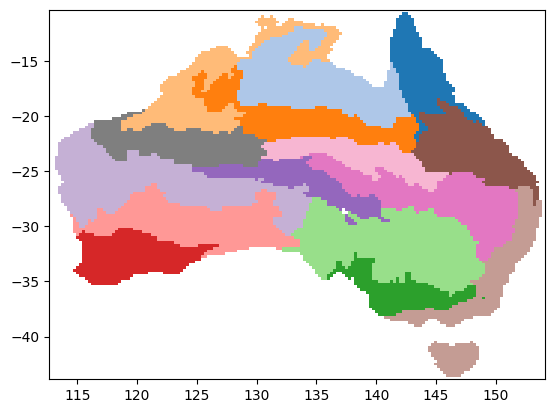

In [9]:
plt.pcolor(lsmdf.longitude,lsmdf.latitude,idxmap,cmap='tab20',
           vmin=0.5,vmax=20.5,alpha=1,snap=True,rasterized=True,zorder=-1)

In [10]:
from sklearn.cluster import KMeans

# List to store inertia values
inertia_values = []

# Range of clusters to try (e.g., from 1 to 20 clusters)
cluster_range = range(1, 21)

# Iterate through different cluster sizes
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(rlsmcs5Wmnavg)  # Fit KMeans on the data
    inertia_values.append(kmeans.inertia_)  # Append the inertia (sum of squared distances)

# Plot the elbow method
plt.figure(figsize=(8, 6))
plt.plot(cluster_range, inertia_values, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True)
plt.show()


KeyboardInterrupt



In [61]:
print(pdist[0])
print(pdist[1])
is_symmetric = np.allclose(pdist, pdist.T)

print("Is pdist symmetric?", is_symmetric)

[ 0.          1.95499583 16.69886188 ... 20.59664587 22.34219129
 24.14055809]
[ 1.95499583  0.         17.72212113 ... 21.22212551 23.04925658
 24.91437469]
Is pdist symmetric? True


In [71]:
# check if they are correlation values
print(np.max(rlsmcs5Wmnavg))
print(np.min(rlsmcs5Wmnavg))
print(np.mean(rlsmcs5Wmnavg))

1.0
-0.41164731979370117
0.10978084913288003


C:\Users\bizza\AppData\Local\Temp\ipykernel_27044\4141564237.py:15: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(pc, label='Mean Euclidean Distance')


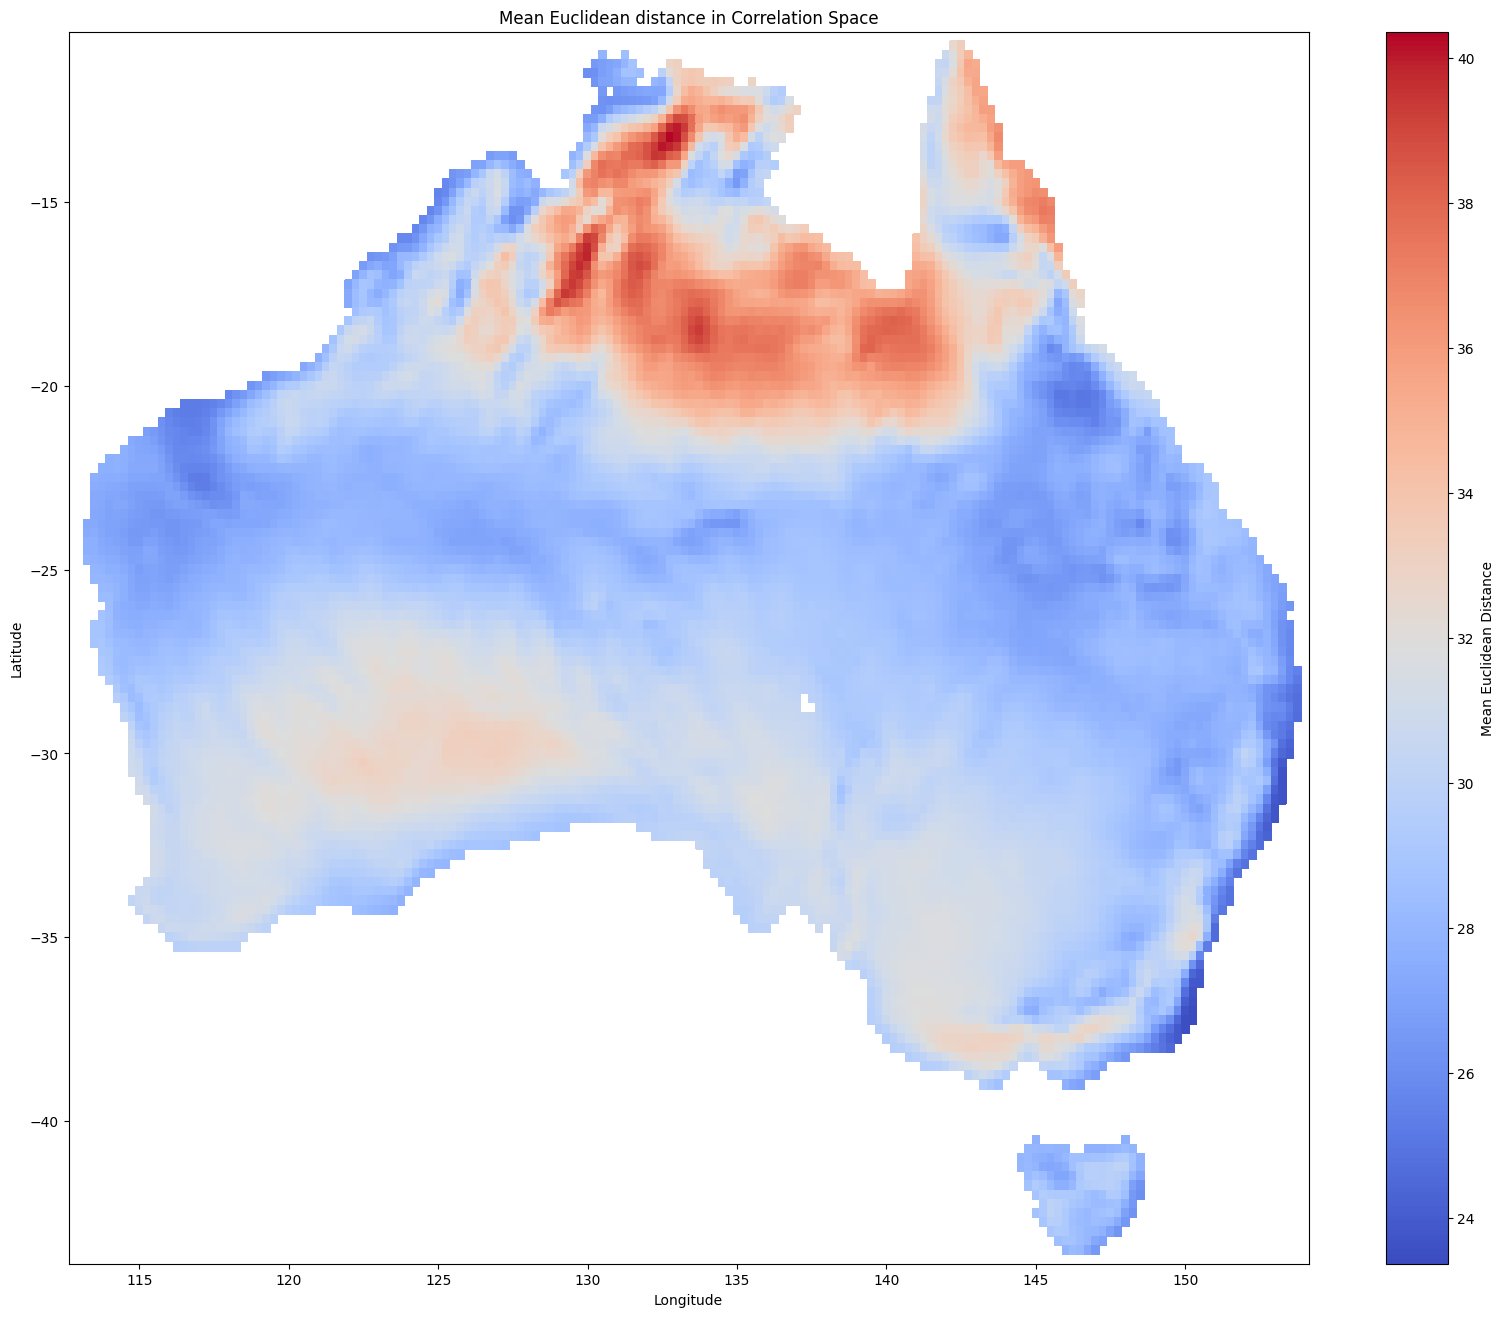

In [70]:
# Heatmap in the distance space

mean_distances = np.mean(pdist, axis=1)
mean_distance_map = np.empty(np.shape(lsmc)) * np.nan 

land_indices = np.argwhere(np.ndarray.flatten(lsmc) == 1)  

# convert land indices to 2D (latitude, longitude) positions
# land_indices is a 2D array with indices of the land locations
land_coords = np.unravel_index(land_indices.flatten(), np.shape(lsmc))

mean_distance_map[land_coords] = mean_distances


plt.figure(figsize=(20, 16))
plt.pcolor(lsmdf.longitude, lsmdf.latitude, mean_distance_map, cmap='coolwarm')
#plt.colorbar(label='TODO: add proper label')
plt.title('Mean Euclidean distance in Correlation Space')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

C:\Users\bizza\AppData\Local\Temp\ipykernel_27044\1819200589.py:14: MatplotlibDeprecationWarning:

Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).



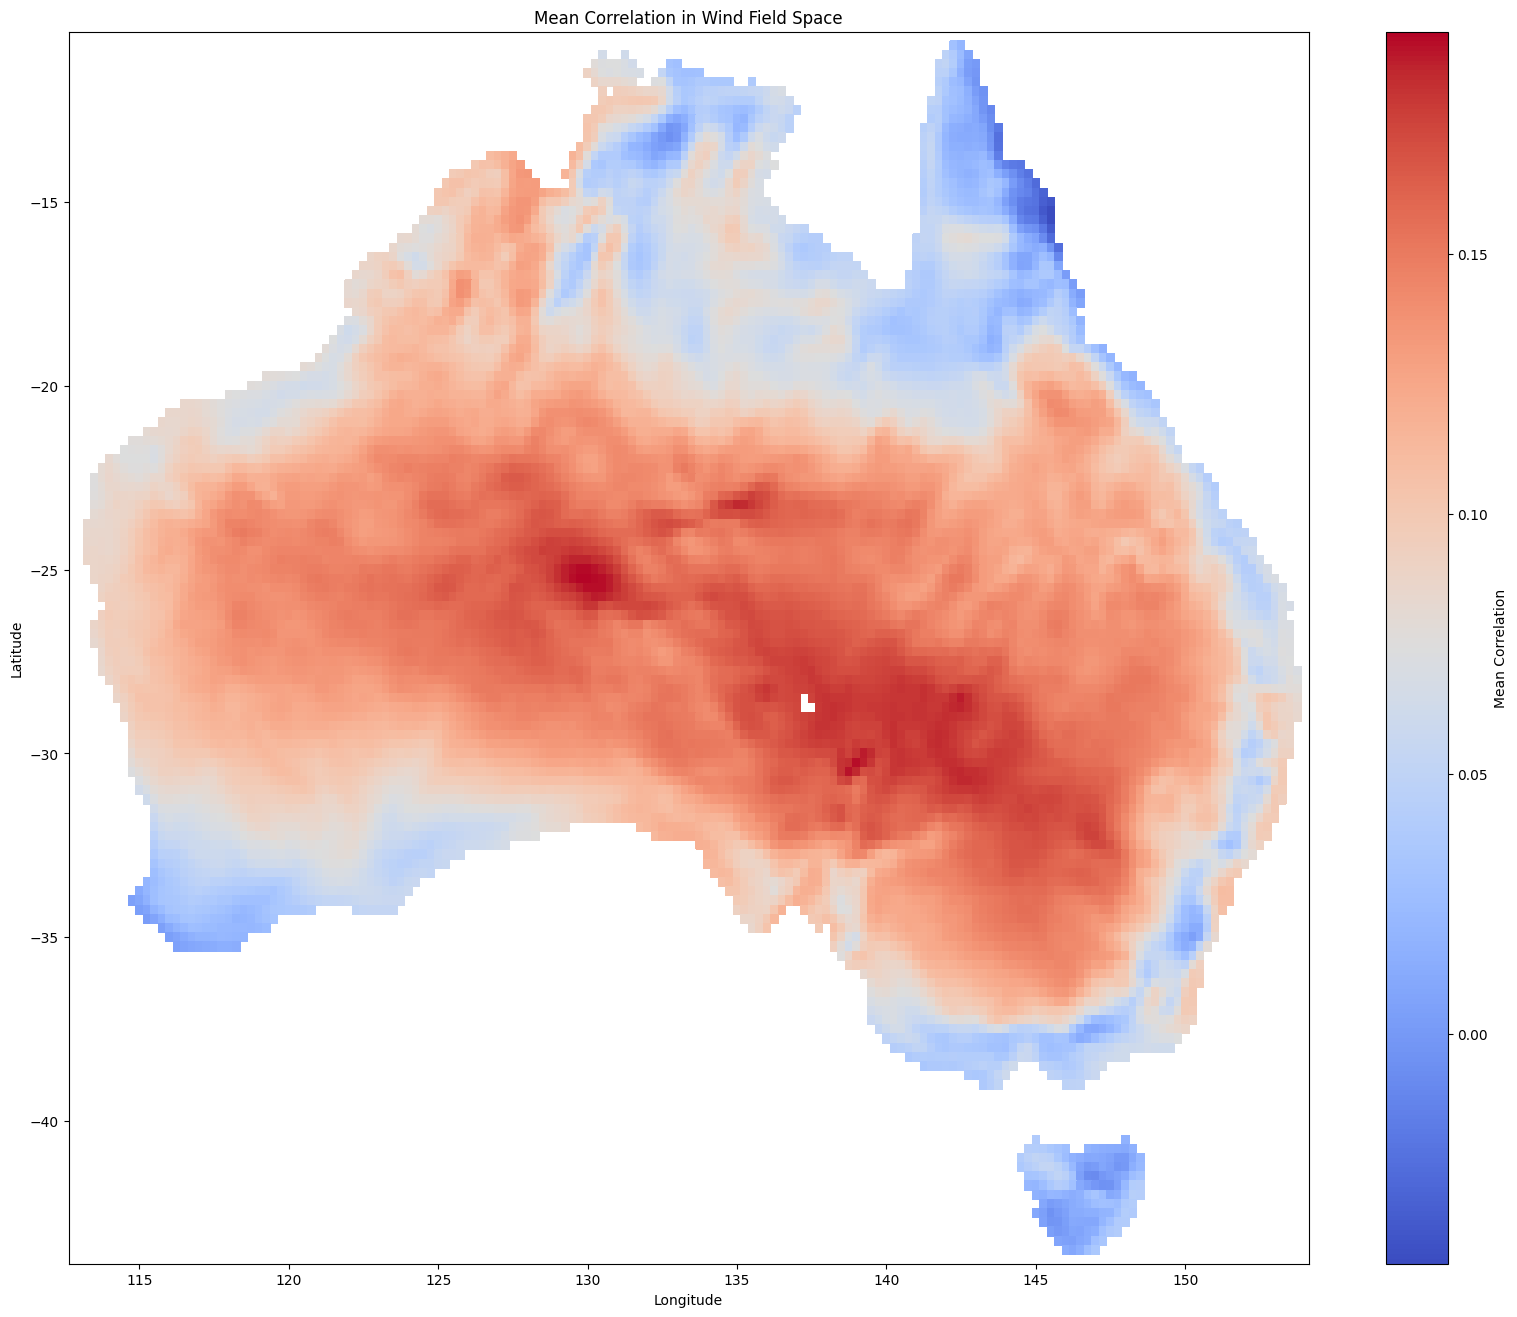

In [93]:
mean_correlations = np.mean(rlsmcs5Wmnavg, axis=1) 
mean_correlation_map = np.empty(np.shape(lsmc)) * np.nan
land_indices = np.argwhere(np.ndarray.flatten(lsmc) == 1)  # Find the land locations

# Convert land indices to 2D (latitude, longitude) positions
land_coords = np.unravel_index(land_indices.flatten(), np.shape(lsmc))

# Assign mean correlations to the corresponding land coordinates
mean_correlation_map[land_coords] = mean_correlations

# Plot the mean correlations on the map
plt.figure(figsize=(20, 16))
plt.pcolor(lsmdf.longitude, lsmdf.latitude, mean_correlation_map, cmap='coolwarm')
plt.colorbar(label='Mean Correlation')  # Label the color bar for clarity
plt.title('Mean Correlation in Wind Field Space')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()